In [1]:
import getpass
import os

from pinecone import Pinecone

if not os.getenv("PINECONE_API_KEY"):
    os.environ["PINECONE_API_KEY"] = getpass.getpass("Enter your Pinecone API key: ")

pinecone_api_key = os.environ.get("PINECONE_API_KEY")

pc = Pinecone(api_key=pinecone_api_key)

In [2]:
from pinecone import ServerlessSpec

index_name = "updated-universe-iub-v3" 
pc.delete_index(index_name)  
if not pc.has_index(index_name):
    pc.create_index(
        name=index_name,
        dimension=768,
        metric="dotproduct",
        spec=ServerlessSpec(cloud="aws", region="us-east-1"),
    )

index = pc.Index(index_name)

/home/muzahid_gtrd224/UniVerse/universe_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

In [ ]:
# import pprint
# from langchain_community.document_loaders import FileSystemBlobLoader
# from langchain_community.document_loaders.generic import GenericLoader
# from langchain_community.document_loaders.parsers import PyPDFParser

# loader = GenericLoader(
#     blob_loader=FileSystemBlobLoader(
#         path="/home/muzahid_gtrd224/UniVerse/pdf_resources",
#         glob="*.pdf",
#     ),
#     blob_parser=PyPDFParser(),
# )
# docs = loader.load()
# print(docs[0].page_content)
# pprint.pp(docs[0].metadata)

Multiple definitions in dictionary at byte 0xa5ec6 for key /Info
Multiple definitions in dictionary at byte 0xa5ed3 for key /Info
Multiple definitions in dictionary at byte 0xa5ee0 for key /Info


Month Dates Events                                                   
4-9 Final exams, Autumn 2024
20 Grades due at Office of the Controller of Examinations & Official end of Autumn 2024
23-27 Course registration for Spring 2025
28 Classes commence
30 Due date for payment of Registration Fees, Spring 2025
15 Shab-E-Barat**
21 Shaheed Day*
4-17 Mid-term exams
26 Independence & National Day*
28 Laylatul Qadr
28 Mar -3 Apr Eid-ul-Fitr**
6 Last date of withdrawal from courses
14 Bangla New Year*
20-22 Faculty Evaluation
28 Classes end
29 Apr - 06 May  Final exams
1 May Day*
11 Budhha Purnima**
14 Grades due at Office of the Controller of Examinations & Official end of Spring 2025
20-22 Course registration for Summer 2025
24 Classes commence
25 Due date for payment of Registration Fees, Summer 2025
Jun’25 5-10 Eid-Ul-Azha**
5-17 Mid-term exams
6 Ashura**
31 Last date of withdrawal from courses
16 Janmastami**
17-19 Faculty Evaluation
21 Classes end
23-28 Final exams
4 Grades due at Office o

In [ ]:
# from langchain_community.document_loaders import UnstructuredPDFLoader

# file_path = "/home/muzahid_gtrd224/UniVerse/pdf_resources/green-book-summer-2025-069842d5-8bb9-4ff2-9a59-4891029b4184.pdf"
# loader = UnstructuredPDFLoader(file_path)

# docs = loader.load()
# docs[0]

Document(metadata={'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/green-book-summer-2025-069842d5-8bb9-4ff2-9a59-4891029b4184.pdf'}, page_content="Independent University, Bangladesh\n\nAspires to be a leading seat of learning and research for developing technologically competent, environmentally responsible, globally conscious future leaders with a strong liberal arts foundation.\n\nGreen Book Undergraduate Program Vol. 33, No. 3\n\nSummer 2025 Semester\n\nThe university reserves the right to revise information, requirements, regulations or financial charges at any time. Whenever changes occur, an effort will be made to notify those concerned.\n\nPlot 16, Block B, Aftabuddin Ahmed Road, Bashundhara Residential Area, Dhaka 1245 Hotline: +880 9612939393 Email: info@iub.edu.bd Website: iub.ac.bd\n\nChancellor & Principal Officers\n\nCHANCELLOR His Excellency Mohammed Shahabuddin Hon’ble President of the People’s Republic of Bangladesh\n\nVICE CHANCELLOR Prof. M. Tamim, PhD (Petro

In [4]:
from langchain_community.document_loaders import UnstructuredPDFLoader
import os

folder_path = "/home/muzahid_gtrd224/UniVerse/pdf_resources"

pdf_files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

all_pdfs = []

for pdf_file in pdf_files:
    pdf_path = os.path.join(folder_path, pdf_file)
    loader = UnstructuredPDFLoader(pdf_path)
    docs = loader.load()

    for doc in docs:
        doc.metadata['filename'] = pdf_file
        doc.metadata['source'] = pdf_path
    
    all_pdfs.extend(docs)
    print(f"Loaded {len(docs)} documents from {pdf_file}")

print(len(all_pdfs))
print(len(pdf_files))


Loaded 1 documents from tentative-academic-calender-2025_ac-14631c72-9715-47fa-a46c-dba2e7047f50.pdf
Loaded 1 documents from 686e64f52b452ae3eb871a60_financial-aid-online-form-ug__autumn25-2e5e310c-5edc-467c-a9cf-6d68ced8ae7f.pdf
Loaded 1 documents from 675813d47741b39a6ddc8dbc_mba-courses-to-be-offered----summer-2025-6cb5ed0d-e917-4b44-aba6-da9aa1477887.pdf
Loaded 1 documents from 68750bb04dd14664d8a58750_financial-aid-autumn-2025-7585b008-b85b-4c97-aeac-fe66572ef8c7.pdf
Loaded 1 documents from IUB At A Glance.pdf
Loaded 1 documents from 6819b0603d9144a3341a9bcf_academic-calendar----summer-2025-b06da8a4-89f4-4de7-94aa-fb132f6958d3.pdf
Loaded 1 documents from 684e5db391a412503f10e8fc_classroom-reallocation-summer-2025-395ae088-0df5-4af2-b599-40800c7b9411.pdf
Loaded 1 documents from 6875f6f14f027ef3d6387660_notification-regarding-online-withdrawal_summer-2025-c94d3e31-e5fe-43d3-ba1c-bdb3a6df62a9.pdf
Loaded 1 documents from final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c

In [5]:
from langchain_community.document_loaders import TextLoader
import os

folder_path = "/home/muzahid_gtrd224/UniVerse/text_files_faculty_information"

txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]

all_texts = []

for txt_file in txt_files:
    txt_path = os.path.join(folder_path, txt_file)
    loader = TextLoader(txt_path)
    docs = loader.load()
    
    for doc in docs:
        doc.metadata['filename'] = txt_file
        doc.metadata['source'] = txt_path
    
    all_texts.extend(docs)
    print(f"Loaded {len(docs)} documents from {txt_file}")

print(len(all_texts))
print(len(txt_files))

Loaded 1 documents from Associate_professor_Saadia_binte_alam_CSE_Department.txt
Loaded 1 documents from Lecturer_Asif_Mahmud_CSE_Department.txt
2
2


In [6]:
from langchain_community.document_loaders import JSONLoader
import os

folder_path = "/home/muzahid_gtrd224/UniVerse/json_resources"
json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]
all_json_docs = []

for json_file in json_files:
    json_path = os.path.join(folder_path, json_file)
    
    # Load JSON file - set text_content=False to handle non-string data
    loader = JSONLoader(file_path=json_path, jq_schema=".", text_content=False)
    docs = loader.load()

    for doc in docs:
        doc.metadata['filename'] = json_file
        doc.metadata['source'] = json_path
    
    all_json_docs.extend(docs)
    print(f"Loaded {len(docs)} documents from {json_file}")

print(f"\nTotal documents: {len(all_json_docs)}")
print(f"Total files: {len(json_files)}")

Loaded 1 documents from COURSE_CSE_421.json
Loaded 1 documents from COURSE_CSE_303L.json
Loaded 1 documents from project_48_Functional_genomics_of_differentially_expressed_ge.json
Loaded 1 documents from COURSE_CSE_203L.json
Loaded 1 documents from COURSE_CSE_213.json
Loaded 1 documents from Kaniz_Fatema.json
Loaded 1 documents from COURSE_CSE_401.json
Loaded 1 documents from COURSE_BNG_201.json
Loaded 1 documents from COURSE_CSE_204L.json
Loaded 1 documents from Md_Tarek_Habib_PhD.json
Loaded 1 documents from project_13_Does_Engagement_in_Digital_Advertising_differ_in_Z.json
Loaded 1 documents from Asif_Mahmood_PhD.json
Loaded 1 documents from project_46_Establishment_of_High_performance_workstation_for_.json
Loaded 1 documents from project_43_Design_and_Development_of_a_Low_cost_EOG_based_Hum.json
Loaded 1 documents from COURSE_CSE_480.json
Loaded 1 documents from COURSE_CSE_449.json
Loaded 1 documents from COURSE_SOC_101.json
Loaded 1 documents from COURSE_CSE_461.json
Loaded 1 docu

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)
split_docs_pdf = text_splitter.split_documents(all_pdfs)

In [ ]:
# from langchain_text_splitters import RecursiveCharacterTextSplitter

# json_text_splitter = RecursiveCharacterTextSplitter(
#     chunk_size=1100,
#     chunk_overlap=100,
# )
# split_json_docs = json_text_splitter.split_documents(all_json_docs)

In [ ]:
# from langchain_text_splitters import RecursiveCharacterTextSplitter

# text_splitter = RecursiveCharacterTextSplitter(
#     chunk_size=1000,
#     chunk_overlap=100,
# )
# split_text_docs = text_splitter.split_documents(all_pdfs)

In [155]:
len(split_docs)

212

In [156]:
len(split_json_docs)

139

In [157]:
len(split_text_docs)

212

In [8]:
doc_list = split_docs_pdf + all_json_docs + all_texts

In [9]:
len(doc_list)

441

In [10]:
from langchain_pinecone import PineconeVectorStore

vector_store = PineconeVectorStore(index=index, embedding=embeddings)

In [11]:
from uuid import uuid4
uuids = [str(uuid4()) for _ in range(len(doc_list))]
vector_store.add_documents(documents=doc_list, ids=uuids)

['1a616350-e3e6-4c5a-b706-c27cfeffe2d2',
 '5e369f41-f3cb-4996-99a0-843d03e7576c',
 '9b1f1d9d-7840-44cf-9495-8c4787c7a2d2',
 'a6e219a7-1765-463f-befb-91c915056cd1',
 '0f651285-7a44-4cf3-95c1-b6ceeabddff2',
 '255eefac-c223-4267-a05e-96999425e877',
 '89af6f0b-5609-4d3c-8626-dacf22f0212e',
 'ee359f8b-a6aa-4323-b97c-41790cd95722',
 '56e8957a-1f1c-44ed-b91e-c27db1edfde1',
 '268a552b-fde2-47e6-a9db-9618fb081c4c',
 'f70732d0-c4bd-4e60-b953-0f02107cf2da',
 'a589f86e-132c-45e8-a63f-d57b48a9498c',
 'e4e31ed7-5a7a-4071-8338-34c3d24031ca',
 'ec816956-708a-4c86-aeae-1a6ee4edc3fa',
 '6a3bcfe8-487c-4bb5-860a-9bc1b9100988',
 '45f6449c-96b1-44e1-9b59-bbbdcff23955',
 'a900beaf-a926-4085-9275-ebca1faa794c',
 'fc989da7-71b1-4055-aab7-68c7b19c5d7d',
 'd4e74d8d-a9fc-4e3b-a2e7-3af94839c28d',
 'f887eed6-4c8f-4677-906c-00968982481f',
 '2d7a053c-e900-46a3-900f-de8c20803f48',
 '56a2bbb9-cf97-46b0-a388-2791fac5489c',
 '8d575034-8ddb-417d-b6d7-585b8f788726',
 '1fe72162-1217-46ea-bfa1-8837dda4e0a0',
 'd7384109-e55a-

In [12]:
retriever = vector_store.as_retriever(
    search_type = "similarity",
    search_kwargs={
        "k": 5
    }
)

In [13]:
user_question = "give me the course list of Computer Science and Engineering"

In [14]:
context = retriever.invoke(user_question)

In [15]:
context

[Document(id='0733e409-54b1-4603-9a59-1743fc82be78', metadata={'filename': 'final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf', 'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf'}, page_content='25321083\n\n25321085\n\n25321086\n\n25321089\n\n25321091\n\n25321092\n\n25321094\n\n25321097\n\n25321099\n\n25321100\n\n25321102\n\n25321103\n\n25321105\n\n25321107\n\n25321108\n\n25321110\n\n25321111\n\n25321113\n\nMajor\n\nComputer Science and Engineering\n\nFinance\n\nMicrobiology\n\nBiochemistry and Biotechnology\n\nEnvironmental Science and Management\n\nFinance\n\nElectrical and Electronic Engineering\n\nMarketing\n\nAccounting\n\nPharmacy (Allowed for 2nd Major) (Selected for viva)\n\nComputer Science and Engineering\n\nElectrical and Electronic Engineering\n\nMicrobiology\n\nMicrobiology\n\nComputer Science and Engineering\n\nLaw (Selected for viva)\n\nFinance\n\nComputer Science an

In [16]:
from langchain_groq import ChatGroq

In [17]:
import os
from dotenv import load_dotenv
load_dotenv()   

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")  

In [18]:
llm = ChatGroq(
    model = "meta-llama/llama-4-scout-17b-16e-instruct"
)

In [19]:
prompt = f"""
You are a helpful assistant with access to university documents, including policies and procedures. Your task is to answer {user_question} by extracting relevant information from these documents. Base your answers solely on the content of the provided documents. Do not use external knowledge or make assumptions beyond what is explicitly stated in the documents. Provide accurate and concise answers, citing the specific document and section where the information was found, if possible. If the answer to a question cannot be found in the provided documents, inform the user politely and suggest alternative resources or actions they can take. Respond in a friendly and professional manner, ensuring that the user feels supported and informed.
{context}
"""

llm.invoke(prompt)

AIMessage(content="I can provide information on the course list of Computer Science and Engineering based on the provided documents. The documents appear to be a list of student results for the summer 2025 semester.\n\nTo extract the course list of Computer Science and Engineering, I will review the provided documents.\n\n## Course List of Computer Science and Engineering\n\nThe course list of Computer Science and Engineering mentioned in the documents are:\n\n- Computer Science and Engineering \n- Computer Science \n- Computer Engineering \n\nThese courses are mentioned across multiple documents:\n\n- Document(id='0733e409-54b1-4603-9a59-1743fc82be78', metadata={'filename': 'final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf', 'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf'})\n- Document(id='3835c313-8890-4df5-a648-c166e1a673fa', metadata={'filename': 'final-result-summer-2025-s

AIMessage(content="I can provide information on the course list of Computer Science and Engineering based on the provided documents. The documents appear to be a list of student results for the summer 2025 semester.\n\nTo extract the course list of Computer Science and Engineering, I will review the provided documents.\n\n## Course List of Computer Science and Engineering\n\nThe course list of Computer Science and Engineering mentioned in the documents are:\n\n- Computer Science and Engineering \n- Computer Science \n- Computer Engineering \n\nThese courses are mentioned across multiple documents:\n\n- Document(id='0733e409-54b1-4603-9a59-1743fc82be78', metadata={'filename': 'final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf', 'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf'})\n- Document(id='3835c313-8890-4df5-a648-c166e1a673fa', metadata={'filename': 'final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf', 'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf'})\n- Document(id='d8b4d7b1-b4d0-47da-8421-48fddb0928f2', metadata={'filename': 'final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf', 'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf'})\n- Document(id='96928e9a-78bd-4974-a9a1-56658d2f0b24', metadata={'filename': 'final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf', 'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf'})\n- Document(id='0155dddd-dd61-48c4-84bb-29b6bb4b65db', metadata={'filename': 'final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf', 'source': '/home/muzahid_gtrd224/UniVerse/pdf_resources/final-result-summer-2025-semester-fbd3855a-6f13-4904-8ba2-08709c0e2e86.pdf'})\n\n## Detailed Information\n\nFor detailed information about the course, such as course descriptions, credit hours, or prerequisites, I recommend checking the university's official website or contacting the Computer Science and Engineering department directly.\n\n## Additional Resources\n\nIf you need more information about the course list or other academic programs, you can:\n\n1. Visit the university's official website.\n2. Contact the Computer Science and Engineering department directly.\n3. Check the university's course catalog or academic policies document.\n\nI'm here to help you with any further questions or provide information based on the provided documents.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 827, 'prompt_tokens': 2138, 'total_tokens': 2965, 'completion_time': 1.957225807, 'prompt_time': 0.08543322, 'queue_time': 0.04655017, 'total_time': 2.042659027}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--af0adb8b-1468-4b94-82a5-4489fc625c81-0', usage_metadata={'input_tokens': 2138, 'output_tokens': 827, 'total_tokens': 2965})


In [20]:
def format_docs(retriever_docs):
    context_text = "\n\n".join(doc.page_content for doc in retriever_docs)
    return context_text

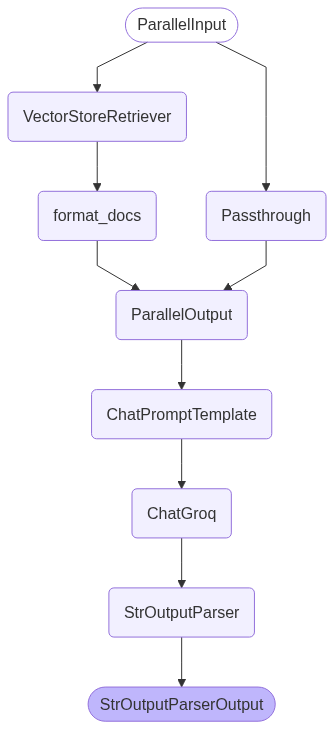

In [21]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate
from IPython.display import display, Image

prompt = ChatPromptTemplate.from_template("""
Answer the question based on the following context:
You are a helpful assistant with access to university documents, including policies and procedures. Your task is to answer {user_question} by extracting relevant information from these documents. Base your answers solely on the content of the provided documents. Do not use external knowledge or make assumptions beyond what is explicitly stated in the documents. Provide accurate and concise answers, citing the specific document and section where the information was found, if possible. If the answer to a question cannot be found in the provided documents, inform the user politely and suggest alternative resources or actions they can take. Respond in a friendly and professional manner, ensuring that the user feels supported and informed.
{context}
Answer:
""")

rag_chain = (
    {
        "context": retriever | format_docs,
        "user_question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

display(Image(rag_chain.get_graph().draw_mermaid_png()))

In [26]:
question = "Give me the email address of M Ashraful Amin, who is a Professor of CSE Department"
response = rag_chain.invoke(question)
print(response)

The email address of M Ashraful Amin, who is a Professor in the CSE Department, is:

aminmdashraful@iub.edu.bd

This information was found in the provided document, specifically in the profile information for M Ashraful Amin, which states:

{"profile_link": "https://iub.ac.bd/academics/departments/cse/faculty-and-staff/aminmdashraful", "faculty_name": "M Ashraful Amin", "designation": "Professor, Dept. of CSE", ... "email": "aminmdashraful@iub.edu.bd"}
